In [25]:
import ISLP.models
import statsmodels.stats.anova
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize

## Import dataset

In [15]:
boston = load_data("Boston")
y = boston["medv"]

In [16]:
X = MS([ISLP.models.poly("lstat", degree=2), "age"]).fit_transform(boston)
model = sm.OLS(y,X)
results = model.fit()
summarize(results)

# poly(stat, degree=2)[0] -> Linear form of "lstat"
# poly(stat, degree=2)[1] -> Quadratic form of "lstat"

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [17]:
X = MS([ISLP.models.poly("lstat", degree=2, raw=True), "age"]).fit_transform(boston)
model = sm.OLS(y,X)
results = model.fit()
summarize(results)

# std. error of intercept increased due to the collinearity between lstat and lstat^2 (as as raw=True so there is no orthogonality in between which gives rises to the form lstat = 20 , lstat^2 = 400)

,coef,std err,t,P>|t|
intercept,41.2885,0.873,47.284,0.0
"poly(lstat, degree=2, raw=True)[0]",-2.6883,0.131,-20.502,0.0
"poly(lstat, degree=2, raw=True)[1]",0.0495,0.004,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [18]:
X1 = MS(["lstat", "age"]).fit_transform(boston)
model1 = sm.OLS(y, X1)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [26]:
statsmodels.stats.anova.anova_lm(results1, results)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


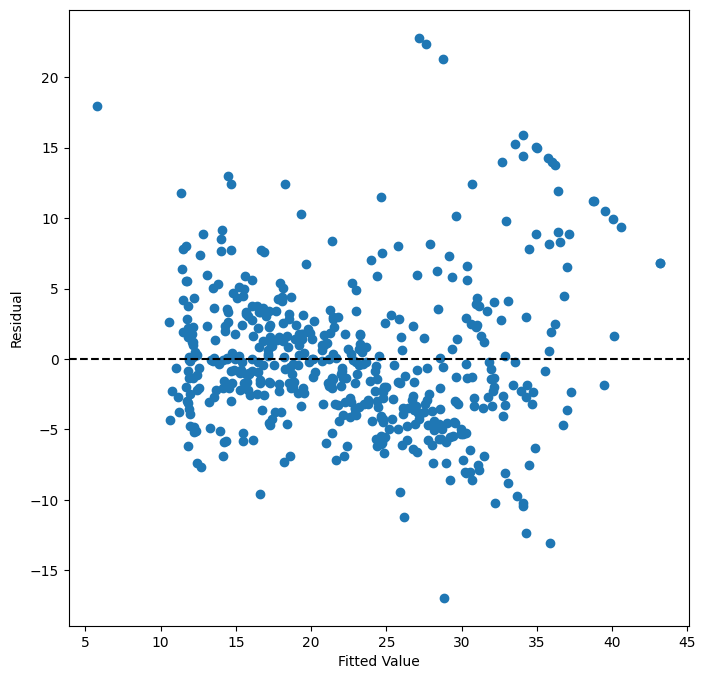

In [29]:
ax = plt.subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel("Fitted Value")
ax.set_ylabel("Residual")
ax.axhline(0, c="k", ls="--")